# KNN Analysis for CS2 Match Prediction - Team Dataset

In this notebook, we implement a K-Nearest Neighbors (KNN) classifier to predict CS2 match outcomes (`team1_win`). 
KNN is a distance-based algorithm, so feature scaling and selection are critical preprocessing steps.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load the dataset
df = pd.read_csv("../../data/aggregated_rolling_features.csv")
print(f"Initial shape: {df.shape}")
df.head()

Initial shape: (5539, 97)


,Unnamed: 0,team1_win,team1,team2,team1_id,team2_id,game_id,match_id,tournament,bestOf,...,previous_10_games_team2_range_kast,previous_10_games_team2_max_kast,previous_10_games_team2_min_kast,previous_10_games_team2_median_kast,previous_10_games_team2_average_kddiff,previous_10_games_team2_std_kddiff,previous_10_games_team2_range_kddiff,previous_10_games_team2_max_kddiff,previous_10_games_team2_min_kddiff,previous_10_games_team2_median_kddiff
0,0,0,Cloud9,Fnatic,233621,233622,115902,589049,Thunderpick World Championship 2023,3.0,...,0.0,70.000000,70.000000,70.000000,1.000000,0.000000,0.0,1.000000,1.000000,1.000000
1,1,1,Cloud9,Fnatic,233621,233622,115901,589049,Thunderpick World Championship 2023,3.0,...,25.0,83.300000,58.300000,58.300000,-0.600000,3.136877,9.0,4.000000,-5.000000,0.000000
2,2,1,Cloud9,Fnatic,233621,233622,115903,589049,Thunderpick World Championship 2023,3.0,...,17.3,75.000000,57.700000,60.100000,-1.600000,5.885576,17.5,8.500000,-9.000000,-1.500000
3,3,1,Monte,Wildcard Gaming,233631,233632,115904,589047,Thunderpick World Championship 2023,3.0,...,0.0,71.535484,71.535484,71.535484,-0.032258,0.000000,0.0,-0.032258,-0.032258,-0.032258
4,4,1,Monte,Wildcard Gaming,233631,233632,115906,589047,Thunderpick World Championship 2023,3.0,...,33.3,60.000000,26.700000,33.300000,-9.000000,2.280351,6.0,-6.000000,-12.000000,-9.000000


In [4]:
# Preprocessing
# Convert datetime to datetime objects and sort chronologically
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

# Define columns to drop (non-features)
cols_to_drop = [
    'Unnamed: 0',
    'team1', 'team2', 
    'team1_id', 'team2_id', 
    'game_id', 'match_id', 'tournament',
    'map_id', 
    'map_name',
    'datetime',
    'team1_player1_id', 'team1_player2_id', 'team1_player3_id', 'team1_player4_id', 'team1_player5_id',
    'team2_player1_id', 'team2_player2_id', 'team2_player3_id', 'team2_player4_id', 'team2_player5_id'
]

print("Data sorted and non-feature columns identified.")

Data sorted and non-feature columns identified.


In [5]:
# Feature Engineering: Create differences between team stats
# This follows the pattern in the reference KNN notebook to capture relative team strength
stats = ['kills', 'deaths', 'assists', 'adr', 'kast', 'kddiff']

for stat in stats:
    t1_col = f'previous_10_games_team1_average_{stat}'
    t2_col = f'previous_10_games_team2_average_{stat}'
    if t1_col in df.columns and t2_col in df.columns:
        df[f'{stat}_diff'] = df[t1_col] - df[t2_col]

df['map_score_diff'] = df['team1_previous_10_average_map_score'] - df['team2_previous_10_average_map_score']

# Update feature list to use diffs and other relevant metrics
feature_cols = [f'{stat}_diff' for stat in stats] + ['map_score_diff', 'bestOf']

# Check if all features exist
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]
y = df['team1_win']

print(f"Selected features: {feature_cols}")
print(f"Features shape: {X.shape}")
X.head()

Selected features: ['kills_diff', 'deaths_diff', 'assists_diff', 'adr_diff', 'kast_diff', 'kddiff_diff', 'map_score_diff', 'bestOf']
Features shape: (5539, 8)


,kills_diff,deaths_diff,assists_diff,adr_diff,kast_diff,kddiff_diff,map_score_diff,bestOf
0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,3.0
1,0.6,-0.6,-3.2,0.52,1.68,1.2,0.0,3.0
2,1.5,-1.6,-0.8,3.11,8.47,3.1,0.0,3.0
3,0.0,0.0,0.0,0.00,0.00,0.0,0.0,3.0
4,9.0,-9.0,3.0,46.80,48.00,18.0,0.0,3.0


In [6]:
# Time-based 80/20 split
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 4431, Test size: 1108


In [7]:
# KNN is distance-based, so scaling is required
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled.")

Features scaled.


In [8]:
# Tune K
results = []
for k in range(1, 101):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append({"k": k, "accuracy": acc})

results_df = pd.DataFrame(results)
best_k_row = results_df.loc[results_df['accuracy'].idxmax()]
best_k = int(best_k_row['k'])
print(f"Best K: {best_k} with Accuracy: {best_k_row['accuracy']:.4f}")

Best K: 76 with Accuracy: 0.5695


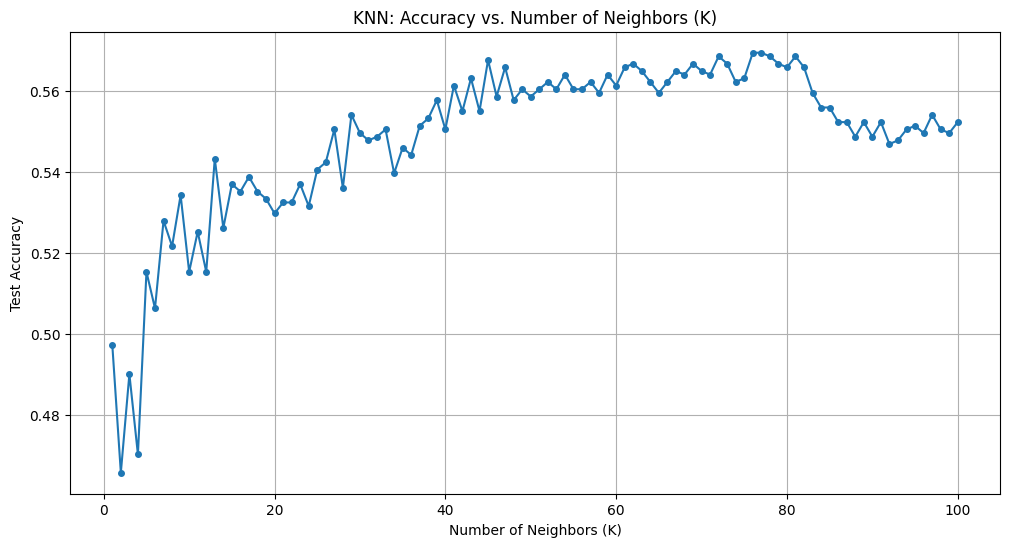

In [9]:
# Visualize K vs Accuracy
plt.figure(figsize=(12, 6))
plt.plot(results_df['k'], results_df['accuracy'], marker='o', linestyle='-', markersize=4)
plt.title('KNN: Accuracy vs. Number of Neighbors (K)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

In [10]:
# Final Evaluation with Best K
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_final)
conf_matrix = confusion_matrix(y_test, y_pred_final)
class_report = classification_report(y_test, y_pred_final)

print(f"Final Accuracy (K={best_k}): {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Final Accuracy (K=76): 0.5695

Confusion Matrix:
[[163 326]
 [151 468]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.33      0.41       489
           1       0.59      0.76      0.66       619

    accuracy                           0.57      1108
   macro avg       0.55      0.54      0.53      1108
weighted avg       0.56      0.57      0.55      1108



In [11]:
# Baseline Comparison (Majority Class)
baseline_acc = y_test.value_counts(normalize=True).max()
print(f"Baseline Accuracy (Majority Class): {baseline_acc:.4f}")

Baseline Accuracy (Majority Class): 0.5587


# DEMO

In [18]:
entry_idx = 5078
entry = X_test.loc[entry_idx]
entry_predicted = knn_final.predict([entry])
display(entry)
display(entry_predicted)

kills_diff        1.960
deaths_diff       0.660
assists_diff      0.060
adr_diff          4.114
kast_diff         0.762
kddiff_diff       1.300
map_score_diff   -1.100
bestOf            3.000
Name: 5078, dtype: float64

array([1])